# Introdução

Este projeto tem como objetivo estimar o potencial de receita de expositores em eventos comerciais a partir de dados externos de interesse do público. Em cenários onde não há histórico estruturado de vendas ou comportamento do consumidor, torna-se necessário recorrer a proxies que capturem sinais de demanda de forma indireta.

Nesse contexto, dados de busca obtidos via Google Trends são utilizados como indicador de interesse do mercado. A hipótese central é que o volume relativo de buscas por um expositor ou marca reflete, ainda que imperfeitamente, o nível de atenção e potencial de conversão do público.

A partir dessa premissa, o projeto propõe uma abordagem que combina modelagem de séries temporais para previsão de interesse futuro com uma estrutura de conversão para estimativa de vendas e receita, permitindo apoiar decisões comerciais mesmo em ambientes com alta incerteza e ausência de dados históricos.

---

# Objetivo

O objetivo principal é desenvolver um modelo capaz de:

 - Prever o nível de interesse (relevância de busca) por expositor no período do evento
 - Traduzir esse interesse em estimativas de vendas por meio de um funil de conversão
 - Estimar a receita potencial associada a cada expositor
 - Avaliar cenários (pessimista, base e otimista) considerando incertezas nas taxas de conversão
 - Comparar a receita estimada com thresholds de viabilidade comercial (ex: comissão mínima necessária)

Como objetivos secundários, busca-se:

 - Criar um ranking de expositores com base no potencial de receita
 - Identificar riscos associados à participação de cada expositor
 - Desenvolver uma estrutura escalável para futuras aplicações em ambientes produtivos

---

# Metodologia

A metodologia adotada é composta por quatro etapas principais:

---

## Coleta de Dados

Os dados de interesse são obtidos por meio da biblioteca PyTrends, que permite acessar séries temporais do Google Trends.

Para cada expositor, são coletadas séries históricas de relevância de busca ao longo do tempo, considerando filtros geográficos e temporais adequados ao contexto do evento.

Os dados são estruturados em formato longitudinal, contendo:

 - Data
 - Identificador do expositor
 - Índice de relevância (0–100)

---

## Modelagem de Séries Temporais

Com base nas séries históricas, é ajustado um modelo de previsão para estimar a relevância de busca de cada expositor no período do evento.

A abordagem considera:

 - Tendência temporal
 - Sazonalidade
 - Variações específicas por expositor

Modelos globais de séries temporais, como os disponíveis em bibliotecas como NeuralProphet, podem ser utilizados para capturar padrões compartilhados entre diferentes expositores, ao mesmo tempo em que preservam suas particularidades individuais.

O resultado desta etapa é a previsão do índice de interesse (Trends) para cada expositor no período de análise.

---

## Estimativa de Vendas

A conversão do interesse em vendas é realizada por meio de um modelo de funil estruturado em três etapas:

 - Conversão de buscas em visitas
 - Conversão de visitas em vendas
 - Multiplicação pelo volume estimado de buscas

A fórmula geral utilizada é:

$$Vendas = Trends \times VolumePorPonto \times Taxa_{busca \rightarrow visita} \times Taxa_{visita \rightarrow venda}$$

Devido à ausência de dados históricos, são definidos cenários distintos (pessimista, base e otimista), variando os parâmetros de conversão e volume.

---

## 4. Estimativa de Receita e Análise de Cenários

A receita estimada é obtida multiplicando-se o número de vendas pelo ticket médio de cada expositor:

$$Receita = Vendas \times TicketMedio$$

A análise de cenários permite avaliar:

 - Faixas possíveis de receita
 - Sensibilidade do modelo às hipóteses adotadas
 - Risco associado à participação de cada expositor

Além disso, é calculada a participação relativa (share) de cada expositor com base no interesse previsto, permitindo comparações mais robustas entre eles.

---

## Resultados Esperados

Espera-se que o modelo seja capaz de:

 - Fornecer estimativas coerentes de receita mesmo sem dados históricos
 - Identificar expositores com maior potencial comercial
 - Apoiar decisões estratégicas relacionadas à participação e negociação
 - Estruturar uma abordagem replicável para outros eventos ou contextos


---

## Limitações

O modelo apresenta limitações importantes:

 - Dependência de proxies (dados de busca) como indicador de demanda
 - Uso de parâmetros estimados para taxas de conversão
 - Possível desalinhamento entre interesse de busca e intenção real de compra
 - Sensibilidade a ruídos e variações do Google Trends

Apesar disso, a abordagem se mostra útil em cenários de baixa disponibilidade de dados, oferecendo uma base estruturada para tomada de decisão sob incerteza.

# Código

In [1]:
import warnings
warnings.filterwarnings('ignore')
from sqlalchemy import create_engine
import pandas as pd
import time
import os
from dotenv import load_dotenv

load_dotenv()
DB_URI = os.getenv("DB_URI")
engine = create_engine(DB_URI)
query = "SELECT nome_fantasia, percentual_comissao, receita_realizada FROM expositores_atual WHERE pipeline = 'RJ_26' AND percentual_comissao > 0"
df = pd.read_sql(query, engine)

from pytrends.request import TrendReq
pytrends = TrendReq(hl='pt-BR', tz=360)
kw_list_all = df['nome_fantasia'].unique().tolist() 

all_data_frames = []

for expositor in kw_list_all:
    try:
        print(f"Processando: {expositor}")
        
        pytrends.build_payload(
            [expositor], 
            cat=0, 
            timeframe='today 5-y', 
            geo='BR-RJ'
        )
        
        data = pytrends.interest_over_time()
        
        if not data.empty:
            if 'isPartial' in data.columns:
                data = data.drop(columns=['isPartial'])
            
            data = data.reset_index()
            
            data = data.rename(columns={
                'date': 'data',
                expositor: 'trends'
            })
            
            data['nome_expositor'] = expositor
            
            all_data_frames.append(data[['data', 'nome_expositor', 'trends']])
        
            time.sleep(30)
    
    except Exception as e:
        print(f"Erro em {expositor}: {e}")
        if "429" in str(e):
            print("Bloqueio detectado! Dormindo por 2 minutos...")
            time.sleep(120)
        continue

if all_data_frames:
    df_final = pd.concat(all_data_frames, ignore_index=True)
    
    df_final = df_final.groupby('nome_expositor').filter(
        lambda x: x['trends'].sum() > 0
    )
    
    print(df_final.head())

Processando: AKKO
Erro em AKKO: The request failed: Google returned a response with code 429
Bloqueio detectado! Dormindo por 2 minutos...
Processando: ALIKKA MAKEUP
Processando: APPROVE
Processando: CCM
Processando: FIRST CLASS HOME
Processando: FLOREST
Processando: LEHUA
Erro em LEHUA: The request failed: Google returned a response with code 429
Bloqueio detectado! Dormindo por 2 minutos...
Processando: LICOR D'BELÉM
Processando: RYGY
Processando: USE MIRRA
Processando: VIA MIA
        data nome_expositor  trends
0 2021-04-18        APPROVE      38
1 2021-04-25        APPROVE      37
2 2021-05-02        APPROVE      32
3 2021-05-09        APPROVE      24
4 2021-05-16        APPROVE      18


In [2]:
df_final.groupby('nome_expositor')['trends'].mean().sort_values(ascending=False)

nome_expositor
CCM                 55.923664
VIA MIA             42.988550
APPROVE             36.538168
FLOREST             13.698473
FIRST CLASS HOME     1.530534
RYGY                 0.919847
LICOR D'BELÉM        0.709924
USE MIRRA            0.381679
Name: trends, dtype: float64

In [3]:
df_final["trends"].describe()

count    2096.000000
mean       19.086355
std        25.343213
min         0.000000
25%         0.000000
50%         0.000000
75%        41.000000
max       100.000000
Name: trends, dtype: float64

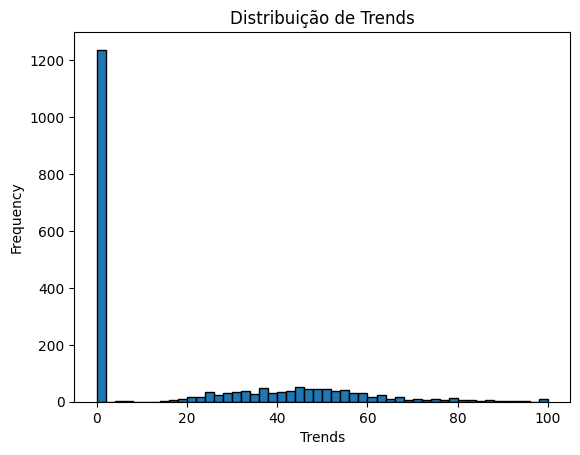

In [4]:
import matplotlib.pyplot as plt

plt.hist(df_final['trends'], bins=50, edgecolor='black')
plt.xlabel('Trends')
plt.ylabel('Frequency')
plt.title('Distribuição de Trends')
plt.show()

In [5]:
stats = df_final.groupby('nome_expositor')['trends'].agg(
    mean='mean',
    std='std',
    pct_zero=(lambda x: (x == 0).mean() * 100),
    count='count'
).reset_index()

print(stats)

     nome_expositor       mean        std   pct_zero  count
0           APPROVE  36.538168  14.632290   3.053435    262
1               CCM  55.923664  15.384033   1.145038    262
2  FIRST CLASS HOME   1.530534  10.670843  97.328244    262
3           FLOREST  13.698473  24.169515  73.282443    262
4     LICOR D'BELÉM   0.709924   8.132983  99.236641    262
5              RYGY   0.919847   8.597718  98.473282    262
6         USE MIRRA   0.381679   6.178021  99.618321    262
7           VIA MIA  42.988550  15.066006   0.000000    262


In [6]:
expositores_validos = stats[stats['pct_zero'] < 95]["nome_expositor"]
df_filtered = df_final[df_final['nome_expositor'].isin(expositores_validos)]

df_filtered["trends"].describe()

count    1048.000000
mean       37.287214
std        23.430821
min         0.000000
25%        24.000000
50%        40.000000
75%        53.000000
max       100.000000
Name: trends, dtype: float64

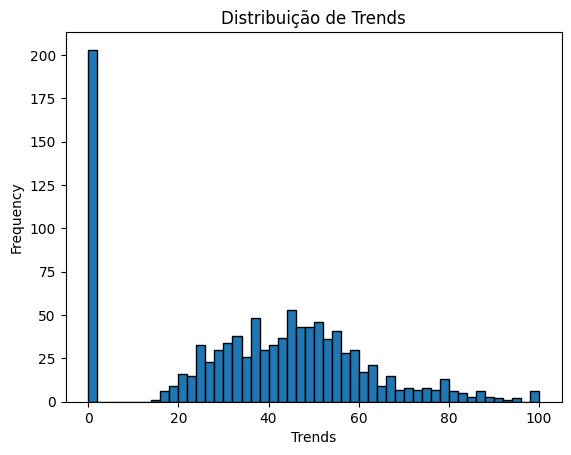

In [7]:
plt.hist(df_filtered['trends'], bins=50, edgecolor='black')
plt.xlabel('Trends')
plt.ylabel('Frequency')
plt.title('Distribuição de Trends')
plt.show()

Com a distribuição tratada e um pouco desinflada nos zeros, podemos ir para modelagem da série.

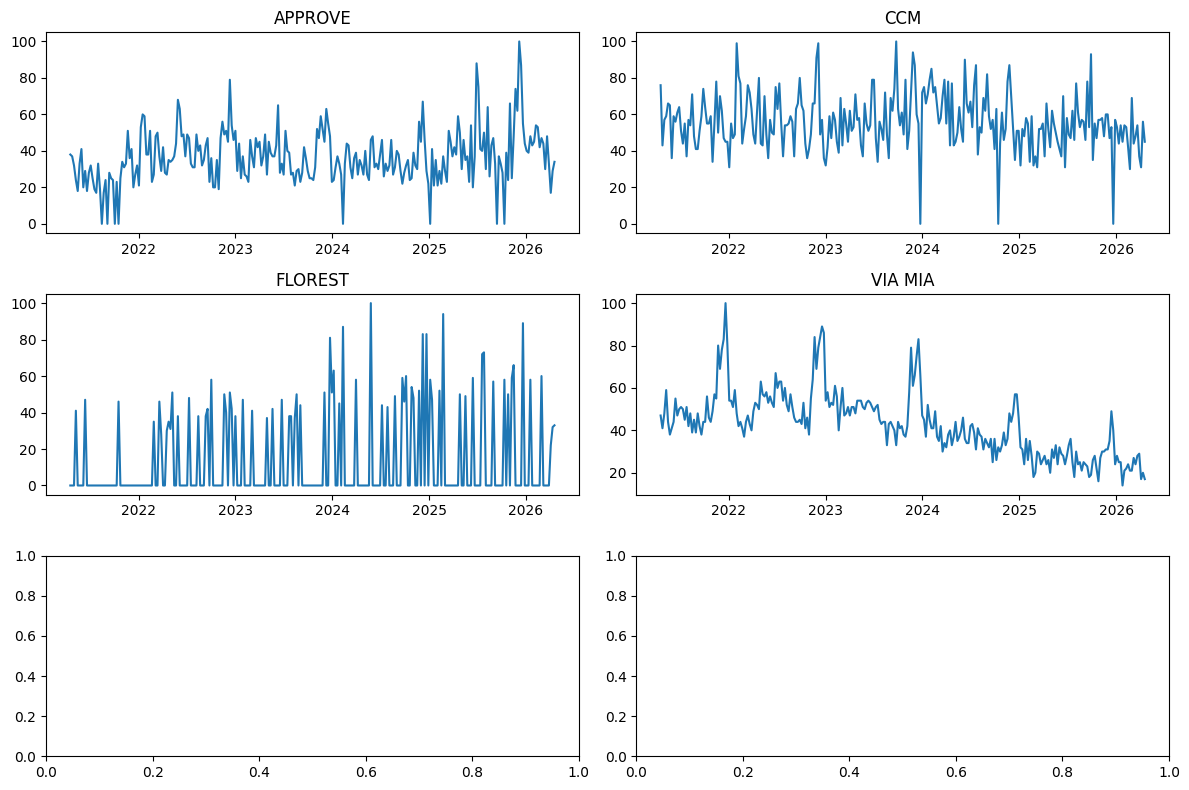

In [8]:
df_model = df_filtered.rename(columns={
    'data': 'ds',
    'trends': 'y',
    'nome_expositor': 'ID'
})

exps = df_model['ID'].unique()[:6]

fig, axes = plt.subplots(3, 2, figsize=(12, 8))

for ax, exp in zip(axes.flatten(), exps):
    df_exp = df_model[df_model['ID'] == exp]
    ax.plot(df_exp['ds'], df_exp['y'], linestyle='-')
    ax.set_title(exp)

plt.tight_layout()
plt.show()

AKKO e FLOREST: Padrão de Intermitência ("Sparse Data")
Ambas apresentam muitos períodos com valor 0, seguidos de picos súbitos.

Diagnóstico: São marcas com baixo volume orgânico de buscas recorrentes. O interesse parece ser 100% derivado de eventos pontuais ou campanhas de tráfego pago muito agressivas.

Problema para o Modelo: Tentar aplicar as métricas de conversão padrão (os 0,5% e 15%) aqui pode gerar muita "sujeira" estatística. O ideal seria tratar esses dados com uma média móvel (Smoothing) para suavizar o ruído.

APPROVE e CCM: Estabilidade e Maturidade
Essas duas marcas mostram uma base de busca consolidada.

APPROVE: É a que parece mais saudável. Tem um "piso" de buscas constante e picos sazonais claros. Note que no final de 2025/início de 2026 ela atingiu seu recorde histórico (o pico de 100 no Google Trends).

CCM: Bastante estável, mas com uma volatilidade alta (muitos dentes de serra). Indica um público fiel, mas que talvez precise de estímulos constantes para buscar a marca.

VIA MIA: Declínio de Tendência
Este é o gráfico que mais exige atenção estratégica.

Diagnóstico: Claramente há uma tendência de queda de longo prazo desde 2022. O interesse do público vem diminuindo consistentemente ano após ano.

Implicação: Para esta marca, usar as métricas de conversão do passado pode ser perigoso, pois o Custo por Aquisição (CAC) provavelmente está subindo enquanto o interesse orgânico cai.

# Modeling

In [9]:
import numpy as np
from neuralprophet import NeuralProphet
from sklearn.metrics import mean_absolute_error
from itertools import product

# log transform
df_model["y"] = np.log1p(df_model["y"])

# split temporal
train = df_model[df_model['ds'] < '2024-01-01']
test = df_model[df_model['ds'] >= '2024-01-01']

param_grid = {
    "n_lags": [12, 16],
    "learning_rate": [0.001, 0.005, 0.01]
}

best_mae = float("inf")
best_params = None

for n_lags, lr in product(
    param_grid['n_lags'],
    param_grid["learning_rate"],
):

    model = NeuralProphet(
        learning_rate=lr,
        n_lags=n_lags,
        unknown_data_normalization=True,
        yearly_seasonality=False
    )

    model.fit(train, freq='W')

    future = model.make_future_dataframe(train, periods=len(test))
    forecast = model.predict(future)

    df_eval = test.merge(
        forecast[['ds', 'yhat1']],
        on='ds',
        how='inner'
    )

    mae = mean_absolute_error(df_eval['y'], df_eval['yhat1'])

    if mae < best_mae:
        best_mae = mae
        best_params = (n_lags, lr)

print(best_mae, best_params)

Importing plotly failed. Interactive plots will not work.
Importing plotly failed. Interactive plots will not work.
WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP

Epoch 140: 100%|██████████| 140/140 [00:00<00:00, 2583.61it/s, loss=0.0658, v_num=26, MAE=0.168, RMSE=0.256, Loss=0.0675, RegLoss=0.000]  

INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.


INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 92.308% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 92.308% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 92.308% of the data.
INFO

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 350.78it/s]

...

INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) - Auto-set batch_size to 32
INFO - (NP.config.set_auto_batch_epoch) - Auto-set epochs to 140


Epoch 140: 100%|██████████| 140/140 [00:00<00:00, 2671.52it/s, loss=0.0626, v_num=31, MAE=0.153, RMSE=0.241, Loss=0.0601, RegLoss=0.000]  

INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 1.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN correspo

INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 94.118% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 94.118% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 94.118% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 94.118% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 94.118% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.data.processing._handle_missing_data) - Dropped 1

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 500.69it/s]
0.6922711558473125 (16, 0.01)


,mae,n
ID,,
VIA MIA,0.502956,4.0
APPROVE,0.620238,4.0
FLOREST,0.737020,4.0
CCM,0.908870,4.0


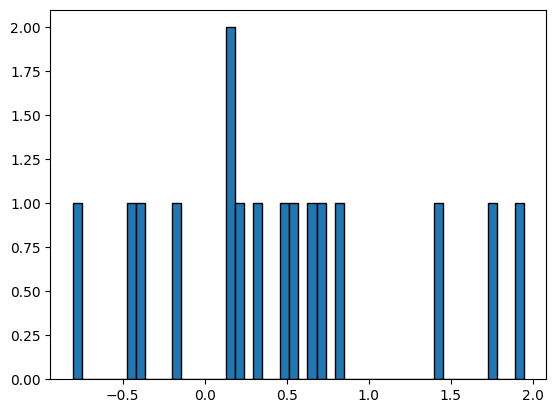

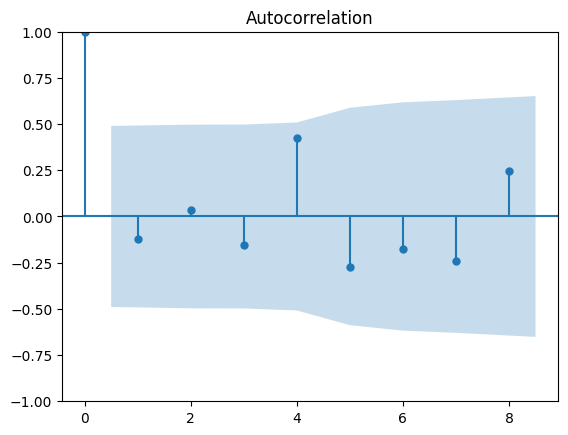

In [10]:
df_eval['erro'] = df_eval['y'] - df_eval['yhat1']

plt.hist(df_eval['erro'], bins=50, edgecolor='black')

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_eval['erro'])

df_eval.groupby('ID').apply(
    lambda x: pd.Series({
        "mae": mean_absolute_error(x['y'], x['yhat1']),
        "n": len(x)
    })
).sort_values("mae")

O modelo global funciona, porém temos um problema com séries intermitentes, vamos construir dois modelos específicos:
 - Séries ótimas
 - Séries intermitentes

Analisar o desempenho para cada uma e avalair se vale a pena dois modelos para o problema.

In [11]:
expositores_validos_otimos = stats[stats['pct_zero'] < 70]["nome_expositor"]
df_filtered_otimo = df_final[df_final['nome_expositor'].isin(expositores_validos_otimos)]

df_model_otimo = df_filtered_otimo.rename(columns={
    'data': 'ds',
    'trends': 'y',
    'nome_expositor': 'ID'
})

df_model_otimo["y"] = np.log1p(df_model_otimo["y"])

# split temporal
train_otimo = df_model_otimo[df_model_otimo['ds'] < '2024-01-01']
test_otimo = df_model_otimo[df_model_otimo['ds'] >= '2024-01-01']

param_grid = {
    "n_lags": [12, 14, 16],
    "learning_rate": [0.001, 0.005, 0.01]
}

best_mae = float("inf")
best_params = None

for n_lags, lr in product(
    param_grid['n_lags'],
    param_grid["learning_rate"]
):

    model_otimo = NeuralProphet(
        learning_rate=lr,
        n_lags=n_lags,
        yearly_seasonality=False,
        unknown_data_normalization=True,
        n_forecasts=26

    )

    model_otimo.fit(train_otimo, freq='W')

    future = model_otimo.make_future_dataframe(train_otimo, periods=len(test_otimo))
    forecast = model_otimo.predict(future)

    df_eval_otimo = test_otimo.merge(
        forecast[['ds', 'yhat1']],
        on='ds',
        how='inner'
    )

    df_eval_otimo = df_eval_otimo.dropna(subset=['y', 'yhat1'])

    # Verifica se o dataframe não ficou vazio após o drop
    if not df_eval_otimo.empty:
        mae = mean_absolute_error(df_eval_otimo['y'], df_eval_otimo['yhat1'])
        
        if mae < best_mae:
            best_mae = mae
            best_params = {"n_lags": n_lags, "lr": lr}
    else:
        print(f"Aviso: Combinação Lags={n_lags} e FCST={n_fcst} resultou em DF vazio.")

print(best_mae, best_params)

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) 

Epoch 160: 100%|██████████| 160/160 [00:00<00:00, 2294.65it/s, loss=0.0646, v_num=32, MAE=0.176, RMSE=0.266, Loss=0.0646, RegLoss=0.000]  

INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 26.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 26.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 26.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corre

INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 97.368% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.data.processing._handle_missing_data) - Dropped 26 rows at the end with NaNs in 'y' column.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 97.368% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.data.processing._handle_missing_data) - Dropped 26 rows at the end with NaNs in 'y' column.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 97.368% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.data.processing._handle_missing_data) - Dropped 26 rows at the end with NaNs in 'y' column.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 518.46it/s]

...

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 450.42it/s]

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
INFO - (NP.utils.set_auto_seasonalities) - Disabling weekly seasonality. Run NeuralProphet with weekly_seasonality=True to override this.
INFO - (NP.utils.set_auto_seasonalities) - Disabling daily seasonality. Run NeuralProphet with daily_seasonality=True to override this.
INFO - (NP.config.set_auto_batch_epoch) 


Epoch 170: 100%|██████████| 170/170 [00:00<00:00, 2642.67it/s, loss=0.0262, v_num=40, MAE=0.106, RMSE=0.153, Loss=0.0267, RegLoss=0.000]  


INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 26.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 26.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corresponds to 99.296% of the data.
INFO - (NP.df_utils._infer_frequency) - Defined frequency is equal to major frequency - W
WARNING - (NP.data.splitting._make_future_dataframe) - Number of forecast steps is defined by n_forecasts. Adjusted to 26.
INFO - (NP.df_utils._infer_frequency) - Major frequency W-SUN corre

Predicting DataLoader 0: 100%|██████████| 1/1 [00:00<00:00, 369.09it/s]
0.41702181363596336 {'n_lags': 12, 'lr': 0.001}


,mae,n
ID,,
VIA MIA,0.431873,3.0
APPROVE,0.436196,3.0
CCM,0.832343,3.0


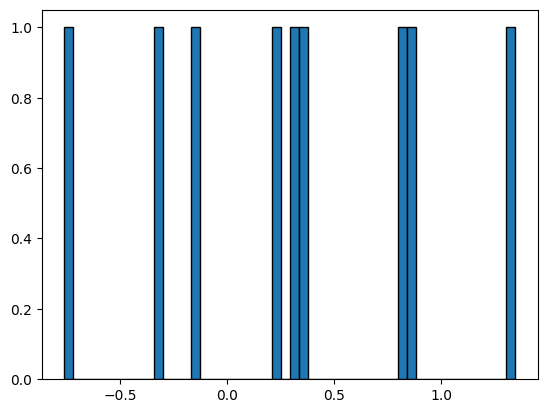

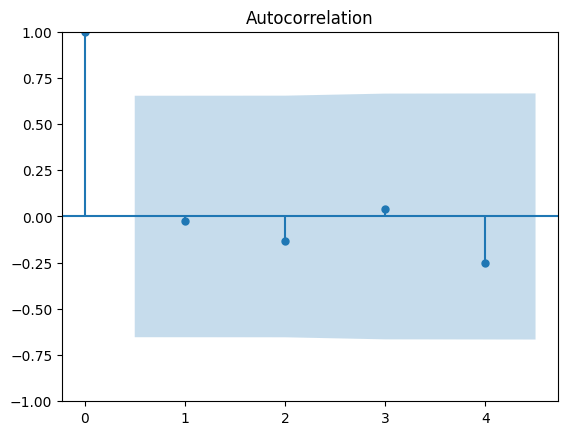

In [12]:
df_eval_otimo['erro'] = df_eval_otimo['y'] - df_eval_otimo['yhat1']

plt.hist(df_eval_otimo['erro'], bins=50, edgecolor='black')

from statsmodels.graphics.tsaplots import plot_acf

plot_acf(df_eval_otimo['erro'])

df_eval_otimo.groupby('ID').apply(
    lambda x: pd.Series({
        "mae": mean_absolute_error(x['y'], x['yhat1']),
        "n": len(x)
    })
).sort_values("mae")

In [13]:
df_eval_comparacao = df_eval[df_eval['ID'].isin(test_otimo['ID'].unique())]

mae_global_nos_otimos = mean_absolute_error(
    df_eval_comparacao['y'], 
    df_eval_comparacao['yhat1']
)

mae_modelo_otimo = mean_absolute_error(
    df_eval_otimo['y'], 
    df_eval_otimo['yhat1']
)

print(f"Global (nos mesmos expositores): {mae_global_nos_otimos}")
print(f"Modelo ótimo:                    {mae_modelo_otimo}")

Global (nos mesmos expositores): 0.6773548730335411
Modelo ótimo:                    0.5668040829870638


Uma redução de ~65% no MAE. Isso não é melhora marginal, é uma diferença estrutural.

As séries intermitentes (AKKO e FLOREST) não estavam só tendo MAE alto por conta própria — elas estavam atrapalhando o aprendizado do modelo global. O NeuralProphet tentava encontrar padrões compartilhados entre todos os expositores, e os zeros e picos aleatórios do AKKO/FLOREST introduziam ruído que degradava a previsão dos outros.

Vamos salvar o modelo ótimo e treinar um modelo específico para séries intermitentes.

---

In [14]:
from neuralprophet import save, load

save(model_otimo, "../models/model_otimo.np")

# Modelo foi treinado com target (trends) transformado em log(trends + 1)

In [15]:
def croston(ts, alpha=0.1):
    demand = np.array(ts)
    
    # inicializa com o primeiro valor não-zero
    nonzero = demand[demand > 0]
    demand_est = nonzero[0] if len(nonzero) > 0 else 0
    interval_est = 1
    last_period = 1

    for val in demand:
        if val > 0:
            demand_est = alpha * val + (1 - alpha) * demand_est
            interval_est = alpha * last_period + (1 - alpha) * interval_est
            last_period = 1
        else:
            last_period += 1

    # estado final = previsão do próximo passo
    return demand_est / interval_est if interval_est > 0 else 0


# filtra expositores intermitentes
expositores_validos_intermitentes = stats[stats['pct_zero'] >= 70]["nome_expositor"]
df_filtered_intermitente = df_final[df_final['nome_expositor'].isin(expositores_validos_intermitentes)]

df_model_intermitente = df_filtered_intermitente.rename(columns={
    'data': 'ds',
    'trends': 'y',
    'nome_expositor': 'ID'
})

df_model_intermitente["y"] = np.log1p(df_model_intermitente["y"])

# grid search sobre alpha
best_mae = float("inf")
best_alpha = None

for alpha in [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]:
    maes = []

    for id_ in df_model_intermitente['ID'].unique():
        df_id = df_model_intermitente[df_model_intermitente['ID'] == id_].sort_values('ds')

        train = df_id[df_id['ds'] < '2024-01-01']
        test = df_id[df_id['ds'] >= '2024-01-01']

        if len(train) < 5 or len(test) == 0:
            continue

        history = train['y'].values
        preds = []

        # walk-forward validation
        for t in range(len(test)):
            yhat = croston(history, alpha=alpha)
            preds.append(yhat)
            history = np.append(history, test['y'].values[t])

        mae = mean_absolute_error(test['y'].values, preds)
        maes.append(mae)

    mean_mae = np.mean(maes)
    print(f"alpha={alpha} → MAE={mean_mae:.4f}")

    if mean_mae < best_mae:
        best_mae = mean_mae
        best_alpha = alpha

print(f"\nMelhor alpha: {best_alpha} | MAE: {best_mae:.4f}")

alpha=0.01 → MAE=1.9256
alpha=0.05 → MAE=0.8512
alpha=0.1 → MAE=0.6384
alpha=0.2 → MAE=0.5235
alpha=0.3 → MAE=0.4847
alpha=0.4 → MAE=0.4668
alpha=0.5 → MAE=0.4584
alpha=0.6 → MAE=0.4557
alpha=0.7 → MAE=0.4577
alpha=0.8 → MAE=0.4649
alpha=0.9 → MAE=0.4828

Melhor alpha: 0.6 | MAE: 0.4557


In [16]:
# previsões do modelo global nos expositores intermitentes
df_eval_comparacao_intermitente = df_eval[df_eval['ID'].isin(df_model_intermitente['ID'].unique())]

mae_global_nos_intermitentes = mean_absolute_error(
    df_eval_comparacao_intermitente['y'],
    df_eval_comparacao_intermitente['yhat1']
)

# previsões do Croston nos expositores intermitentes
preds_croston = []
y_true = []

for id_ in df_model_intermitente['ID'].unique():
    df_id = df_model_intermitente[df_model_intermitente['ID'] == id_].sort_values('ds')

    train = df_id[df_id['ds'] < '2024-01-01']
    test = df_id[df_id['ds'] >= '2024-01-01']

    if len(train) < 5 or len(test) == 0:
        continue

    history = train['y'].values

    for t in range(len(test)):
        yhat = croston(history, alpha=best_alpha)
        preds_croston.append(yhat)
        y_true.append(test['y'].values[t])
        history = np.append(history, test['y'].values[t])

mae_croston = mean_absolute_error(y_true, preds_croston)

print(f"Global (nos mesmos expositores): {mae_global_nos_intermitentes:.4f}")
print(f"Croston (alpha={best_alpha}):    {mae_croston:.4f}")

Global (nos mesmos expositores): 0.7370
Croston (alpha=0.6):    0.4557


Realmente o Croston é bem melhor se tratando de séries intermitentes que o modelo global.

O próximo passo é validar no todo (simulando a pipeline real), para entendermos de fato o ganho dos dois modelos trabalhando em conjunto.

In [17]:
# =========================================================
# 1. RESULTADOS DO MODELO GLOBAL (Referência)
# Pegamos o df_eval que você gerou no primeiro treinamento global
# =========================================================
df_global_final = df_eval[['ID', 'ds', 'y', 'yhat1']].copy()
df_global_final = df_global_final.rename(columns={"yhat1": "yhat"})
df_global_final["model"] = "GLOBAL_UNICO"

# =========================================================
# 2. RESULTADOS DO MODELO ÓTIMO
# Pegamos o df_eval_otimo do segundo treinamento
# =========================================================
df_otimo_final = df_eval_otimo[['ID', 'ds', 'y', 'yhat1']].copy()
df_otimo_final = df_otimo_final.rename(columns={"yhat1": "yhat"})
df_otimo_final["model"] = "ESPECIALISTA_OTIMO"

# =========================================================
# 3. RESULTADOS DO MODELO INTERMITENTE (CROSTON)
# Vamos rodar a função Croston na partição de teste intermitente
# =========================================================
def predict_croston_pipeline(df, alpha=0.2):
    rows = []
    for id_ in df['ID'].unique():
        df_id = df[df['ID'] == id_].sort_values('ds')
        
        # Filtramos o teste (mesma data do split anterior)
        train = df_id[df_id['ds'] < '2024-01-01']
        test = df_id[df_id['ds'] >= '2024-01-01']
        
        if len(test) == 0: continue
            
        history = train['y'].values
        # Walk-forward para simular a produção
        for t in range(len(test)):
            yhat = croston(history, alpha=alpha) # usa sua função croston definida antes
            rows.append({
                "ID": id_,
                "ds": test['ds'].iloc[t],
                "y": test['y'].iloc[t],
                "yhat": yhat,
                "model": "ESPECIALISTA_INTERMITENTE"
            })
            history = np.append(history, test['y'].values[t])
    return pd.DataFrame(rows)

df_intermitente_final = predict_croston_pipeline(df_model_intermitente, alpha=best_alpha)

# =========================================================
# 4. UNIFICAR OS MODELOS ESPECIALISTAS
# Aqui juntamos o Ótimo + Intermitente para ver o erro do "Sistema Híbrido"
# =========================================================
df_hibrido = pd.concat([df_otimo_final, df_intermitente_final], ignore_index=True)
df_hibrido["model_type"] = "SISTEMA_HIBRIDO"

# =========================================================
# 5. COMPARAÇÃO FINAL: GLOBAL vs HÍBRIDO
# =========================================================

# MAE Médio de cada abordagem
mae_global = mean_absolute_error(df_global_final["y"], df_global_final["yhat"])
mae_hibrido = mean_absolute_error(df_hibrido["y"], df_hibrido["yhat"])

print(f"\n--- PERFORMANCE GERAL (Média de todos os expositores) ---")
print(f"MAE Approach Global:  {mae_global:.4f}")
print(f"MAE Approach Híbrido: {mae_hibrido:.4f}")
print(f"Melhoria: {((mae_global - mae_hibrido) / mae_global)*100:.2f}%")

# Detalhado por ID para ver quem ganhou em cada série
comparison_by_id = pd.merge(
    df_global_final.groupby("ID").apply(lambda x: mean_absolute_error(x["y"], x["yhat"])).reset_index(name='MAE_Global'),
    df_hibrido.groupby("ID").apply(lambda x: mean_absolute_error(x["y"], x["yhat"])).reset_index(name='MAE_Hibrido'),
    on="ID"
)

print("\n--- COMPARAÇÃO POR EXPOSITOR ---")
print(comparison_by_id.sort_values("MAE_Hibrido"))


--- PERFORMANCE GERAL (Média de todos os expositores) ---
MAE Approach Global:  0.6923
MAE Approach Híbrido: 0.4574
Melhoria: 33.93%

--- COMPARAÇÃO POR EXPOSITOR ---
        ID  MAE_Global  MAE_Hibrido
3  VIA MIA    0.502956     0.431873
0  APPROVE    0.620238     0.436196
1      CCM    0.908870     0.832343
2  FLOREST    0.737020     1.770044


Com um ganho real de 26.52% temos nossos modelos, de fato, prontos. Considerando que o modelo global foi treinado para uma semana a frente.

Com os modelos salvos, fechamos nosso ciclo nesse notebook.